# Line Table Domain Conversion

In this notebook, we demonstrate the static pre-processing of line tables from the Wavelength domain to the Energy/Frequency domain. This bypasses the need for runtime Jacobian conversions.

In [1]:
import numpy as np
import astropy.units as u
from prism.modeling.models.lines import setup_local_lines, convert_domain_csv
import tempfile
import os

## 1. Create a Wavelength Line Table
We'll set up a local line table in Angstroms.

In [2]:
temp_dir = tempfile.mkdtemp()

# Setup a standard air-wavelength line table
setup_local_lines(min=4000*u.AA, max=7000*u.AA, dirpath=temp_dir, overwrite=True)

print("Created wavelength line tables in:", temp_dir)


Wavelength range set to: [4000.0, 7000.0]
Created wavelength line tables in: /var/folders/0j/jmc_f39n3wj4h991n1dk_0rc0000gn/T/tmpvav9p7ct


## 2. Convert to Energy Domain (eV)
We use the `convert_linetable_domain` helper to statically map the positions to Energy (eV) and appropriately scale the weights by the domain Jacobian.

In [3]:
# Output directory for the energy line tables
energy_dir = os.path.join(temp_dir, 'energy')

# Convert from Wavelength (Angstrom) to Energy (eV)
# Use convert_domain_csv for batch file conversion
convert_domain_csv(
    temp_dir,  # Input directory with .ecsv files
    output_unit=u.eV,  # Target domain
    input_unit=u.AA,  # Input files are in Angstrom (from setup_local_lines)
    output_dir=energy_dir,  # Write converted files to separate directory
    overwrite=True
)

print("Converted line tables stored in:", energy_dir)

Directory /var/folders/0j/jmc_f39n3wj4h991n1dk_0rc0000gn/T/tmpvav9p7ct/energy created.
Converted line tables stored in: /var/folders/0j/jmc_f39n3wj4h991n1dk_0rc0000gn/T/tmpvav9p7ct/energy


## 3. Load the Native Energy Models
Now, models loaded from the energy directory will natively evaluate in eV space!

In [4]:
from astropy.table import QTable
import astropy.units as u

# Verify the conversion worked by reading one of the converted files
converted_files = [f for f in os.listdir(energy_dir) if f.endswith('.ecsv')]
print(f"Converted line tables: {converted_files}")

if converted_files:
    # Load and inspect one of the converted tables
    first_table = QTable.read(os.path.join(energy_dir, converted_files[0]), format='ascii.ecsv')
    print(f"\nInspecting {converted_files[0]}:")
    print(f"  Positions unit: {first_table['position'].unit}")
    print(f"  First few positions: {first_table['position'][:3]}")
    print(f"  Weights (after Jacobian scaling): {first_table['weight']}")
    
print("\n✓ Domain conversion complete! Line positions were converted to eV")
print("  and weights were rescaled by the domain Jacobian to conserve flux.")

Converted line tables: ['feII_forbidden.ecsv', 'oiii.ecsv', 'feii_IZw1.ecsv', 'coronal.ecsv', 'narrow_basic.ecsv', 'narrow_plus.ecsv', 'broad.ecsv', 'helium.ecsv', 'balmer.ecsv', 'nii.ecsv', 'hydrogen.ecsv', 'bowen.ecsv', 'feII_model.ecsv', 'uvfe.ecsv', 'na_doublet.ecsv']

Inspecting feII_forbidden.ecsv:
  Positions unit: eV
  First few positions: [3.01336619 2.98998422 2.96811665] eV
  Weights (after Jacobian scaling):       weight     
-----------------
0.936602509184043
0.899392687872931
0.912694039762674
0.966193093780384
0.936604176391025
0.942106276237942
0.942480583190969
              1.0
0.956753071375129
0.917950658047344
              ...
0.926308717320561
              1.0
0.958935379781419
0.956160767184606
0.908335337175529
0.988631381106737
              1.0
0.925117990590861
              1.0
              1.0
Length = 67 rows

✓ Domain conversion complete! Line positions were converted to eV
  and weights were rescaled by the domain Jacobian to conserve flux.


In [5]:
# Analagously lines in air wavelenght can be converted in vacuum and vice versa
from prism.modeling.models.lines import convert_linetable_medium, convert_medium_csv
from prism.utils.tools import vac_to_air, air_to_vac # core functions

# SHOW EXAMPLES OF USAGE

In [6]:
os.path.join(energy_dir, converted_files[1])

'/var/folders/0j/jmc_f39n3wj4h991n1dk_0rc0000gn/T/tmpvav9p7ct/energy/oiii.ecsv'

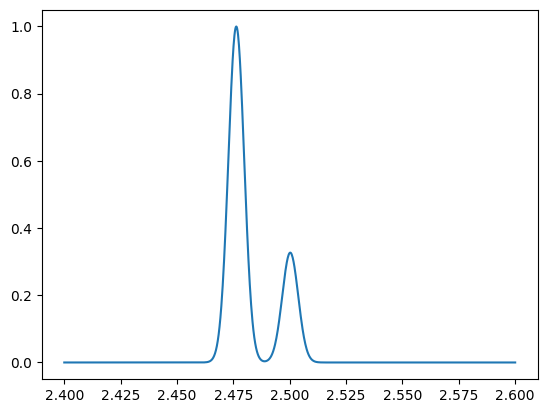

In [7]:
import matplotlib.pyplot as plt
import astropy.units as u
from prism.modeling.models.lines import GaussianLines

x = np.linspace(2.4, 2.6, 1000)

model = GaussianLines.from_csv(
    csv_files=os.path.join(energy_dir, converted_files[1]),
)

plt.figure()
plt.plot(x, model(x)) # Now we see the lines at their position in eV (~2.48 and ~2.5 eV)
plt.show()
